In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
print("Imports done!")

Imports done!


In [2]:
df = pd.read_csv("Dataset_B.csv")

targets = ['r1','r2','r3','D1','D2','D3']
feature_cols = [c for c in df.columns if c not in targets]

X = df[feature_cols].values  # modal features
Y = df[targets].values       # geometry

# Handle NaNs
col_means = np.nanmean(X, axis=0)
inds = np.where(np.isnan(X))
X[inds] = np.take(col_means, inds[1])

# Remove zero variance
stds = X.std(axis=0)
mask = stds > 1e-12
X = X[:, mask]

# Normalize
scaler_X = StandardScaler()
scaler_Y = StandardScaler()
Xn = scaler_X.fit_transform(X)
Yn = scaler_Y.fit_transform(Y)

# Split
X_train, X_test, Y_train, Y_test = train_test_split(
    Xn, Yn, test_size=0.2, random_state=42
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
Y_test_t  = torch.tensor(Y_test,  dtype=torch.float32)

print("Data loaded!")
print("Modal features shape:", X_train_t.shape)
print("Geometry shape:", Y_train_t.shape)

Data loaded!
Modal features shape: torch.Size([3918, 20])
Geometry shape: torch.Size([3918, 6])


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31292\1831768442.py:10: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(X, axis=0)


In [3]:
# Forward Model: geometry (6) → modal features (20)
class ForwardNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 20)
        )
    def forward(self, x):
        return self.net(x)

# Inverse Model: modal features (20) → geometry (6)
class InverseNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(20, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 6)
        )
    def forward(self, x):
        return self.net(x)

print("Models defined!")

Models defined!


In [4]:
forward_model = ForwardNN()
criterion = nn.MSELoss()
optimizer_f = torch.optim.Adam(forward_model.parameters(), lr=0.001)

# For forward model input=geometry, output=modal features
# So we use Y_train as input and X_train as output

Y_train_t_forward = torch.tensor(Y_train, dtype=torch.float32)
X_train_t_forward = torch.tensor(X_train, dtype=torch.float32)

print("Training Forward Model...")
for epoch in range(500):
    forward_model.train()
    optimizer_f.zero_grad()
    pred = forward_model(Y_train_t_forward)
    loss = criterion(pred, X_train_t_forward)
    loss.backward()
    optimizer_f.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss={loss.item():.6f}")

print("Forward Model Training Complete!")

Training Forward Model...
Epoch 0, Loss=1.005962
Epoch 100, Loss=0.057933
Epoch 200, Loss=0.034555
Epoch 300, Loss=0.027384
Epoch 400, Loss=0.024047
Forward Model Training Complete!


In [5]:
# Freeze all parameters of forward model
for param in forward_model.parameters():
    param.requires_grad = False

print("Forward model frozen!")
print("Forward model will NOT update during tandem training")

Forward model frozen!
Forward model will NOT update during tandem training


In [6]:
class TandemNetwork(nn.Module):
    def __init__(self, inverse_model, forward_model):
        super().__init__()
        self.inverse = inverse_model
        self.forward_net = forward_model

    def forward(self, x):
        # Step 1: predict geometry from modal features
        geometry = self.inverse(x)
        # Step 2: reconstruct modal features from geometry
        reconstructed = self.forward_net(geometry)
        return geometry, reconstructed

inverse_model = InverseNN()
tandem = TandemNetwork(inverse_model, forward_model)
print("Tandem Network created!")

Tandem Network created!


In [7]:
optimizer_t = torch.optim.Adam(
    inverse_model.parameters(),  # only inverse updates!
    lr=0.001
)

criterion = nn.MSELoss()
epochs = 500
best_loss = np.inf
best_state = inverse_model.state_dict()
loss_curve = []

print("Training Tandem Network...")
for epoch in range(epochs):
    tandem.train()
    optimizer_t.zero_grad()

    # Forward pass through tandem
    geometry_pred, modal_reconstructed = tandem(X_train_t)

    # Loss 1: geometry should match true geometry
    loss_geom = criterion(geometry_pred, Y_train_t)

    # Loss 2: reconstructed modal should match input modal
    loss_modal = criterion(modal_reconstructed, X_train_t)

    # Combined loss
    loss = loss_geom + 0.5 * loss_modal

    if torch.isnan(loss):
        continue

    loss.backward()
    optimizer_t.step()
    loss_curve.append(loss.item())

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = inverse_model.state_dict()

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Total Loss={loss.item():.6f} | "
              f"Geom Loss={loss_geom.item():.6f} | "
              f"Modal Loss={loss_modal.item():.6f}")

inverse_model.load_state_dict(best_state)
print("\nTandem Training Complete! Best loss:", best_loss)

Training Tandem Network...
Epoch 0 | Total Loss=1.578135 | Geom Loss=1.006868 | Modal Loss=1.142535
Epoch 50 | Total Loss=0.567737 | Geom Loss=0.539789 | Modal Loss=0.055895
Epoch 100 | Total Loss=0.460770 | Geom Loss=0.443653 | Modal Loss=0.034233
Epoch 150 | Total Loss=0.406100 | Geom Loss=0.392423 | Modal Loss=0.027353
Epoch 200 | Total Loss=0.380083 | Geom Loss=0.365475 | Modal Loss=0.029214
Epoch 250 | Total Loss=0.356471 | Geom Loss=0.343822 | Modal Loss=0.025299
Epoch 300 | Total Loss=0.342607 | Geom Loss=0.329611 | Modal Loss=0.025992
Epoch 350 | Total Loss=0.329911 | Geom Loss=0.317663 | Modal Loss=0.024496
Epoch 400 | Total Loss=0.320855 | Geom Loss=0.308060 | Modal Loss=0.025590
Epoch 450 | Total Loss=0.310075 | Geom Loss=0.297883 | Modal Loss=0.024384

Tandem Training Complete! Best loss: 0.3036730885505676


In [8]:
inverse_model.eval()
with torch.no_grad():
    Y_pred_t, _ = tandem(X_test_t)
    Y_pred = Y_pred_t.numpy()

Y_pred = scaler_Y.inverse_transform(Y_pred)
Y_true = scaler_Y.inverse_transform(Y_test)

targets = ['r1','r2','r3','D1','D2','D3']
print("===== Tandem Network Results =====")
for i, t in enumerate(targets):
    r2 = r2_score(Y_true[:, i], Y_pred[:, i])
    print(f"{t}: R²={r2:.4f}")

===== Tandem Network Results =====
r1: R²=0.6342
r2: R²=0.5533
r3: R²=0.2093
D1: R²=0.9004
D2: R²=0.9738
D3: R²=0.5478


In [9]:
# Load normal inverse results
Y_true_normal = np.load("true_inverse_B_FFNN.npy")
Y_pred_normal = np.load("pred_inverse_B_FFNN.npy")

print("===== Comparison =====")
print(f"{'Parameter':<12} {'Normal R²':<12} {'Tandem R²':<12} {'Change'}")
print("-" * 50)
for i, t in enumerate(targets):
    r2_normal = r2_score(Y_true_normal[:, i], Y_pred_normal[:, i])
    r2_tandem = r2_score(Y_true[:, i], Y_pred[:, i])
    change = "↑" if r2_tandem > r2_normal else "↓"
    print(f"{t:<12} {r2_normal:<12.4f} {r2_tandem:<12.4f} {change}")

===== Comparison =====
Parameter    Normal R²    Tandem R²    Change
--------------------------------------------------
r1           0.7038       0.6342       ↓
r2           0.5463       0.5533       ↑
r3           0.1759       0.2093       ↑
D1           0.9197       0.9004       ↓
D2           0.9798       0.9738       ↓
D3           0.5555       0.5478       ↓


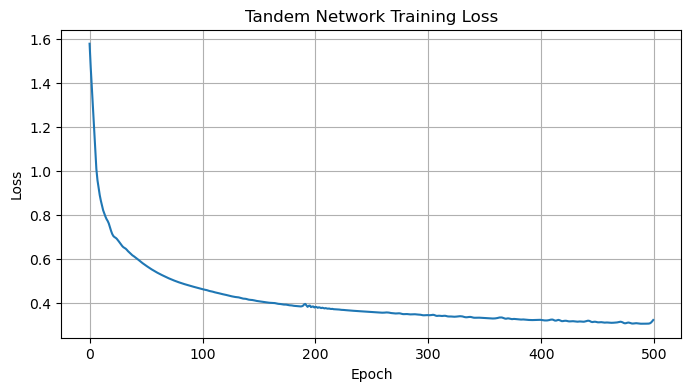

Saved!


In [10]:
# Loss curve
plt.figure(figsize=(8,4))
plt.plot(loss_curve)
plt.title("Tandem Network Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig("tandem_loss.png", dpi=150)
plt.show()

# Save results
np.save("true_tandem.npy", Y_true)
np.save("pred_tandem.npy", Y_pred)
print("Saved!")